In [1]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer


from pgmpy.estimators import BDeuScore, HillClimbSearch
from pgmpy.models import BayesianNetwork


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = "Complete-data.csv"   
TARGET = "Landslide"             
TEST_SIZE = 0.20
STRATIFY = True                  
DISCRETIZE_NUMERIC = False       
K_BINS = 5                       
ESS = 1.0                         

assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "shape:", df.shape)

print("\nColumns and dtypes:")
print(df.dtypes)
print("\nMissing values (per column):")
print(df.isna().sum().to_string())
print("\nTarget distribution:")
print(df[TARGET].value_counts().to_string())
print("\nSample:")
display(df.head())

numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != TARGET]
cat_cols = [c for c in df.columns if c not in numeric_cols]

if numeric_cols:
    num_imputer = SimpleImputer(strategy="median")
    df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

if DISCRETIZE_NUMERIC and numeric_cols:
    kb = KBinsDiscretizer(n_bins=K_BINS, encode="ordinal", strategy="quantile")
    df[numeric_cols] = kb.fit_transform(df[numeric_cols]).astype(int)

df_disc = df.copy()
for c in df_disc.columns:
    df_disc[c] = df_disc[c].astype(int).astype(str) if pd.api.types.is_integer_dtype(df_disc[c]) or pd.api.types.is_float_dtype(df_disc[c]) else df_disc[c].astype(str)

stratify_col = df_disc[TARGET] if STRATIFY else None
train_df, test_df = train_test_split(df_disc, test_size=TEST_SIZE, random_state=SEED, stratify=stratify_col)

train_disc = train_df.reset_index(drop=True)
test_disc  = test_df.reset_index(drop=True)

print(f"\nTrain shape: {train_disc.shape}, Test shape: {test_disc.shape}")
print("Train target counts:")
print(train_disc[TARGET].value_counts().to_string())
print("Test target counts:")
print(test_disc[TARGET].value_counts().to_string())




Loaded: Complete-data.csv shape: (1212, 13)

Columns and dtypes:
Landslide        int64
Aspect           int64
Curvature        int64
Earthquake       int64
Elevation        int64
Flow             int64
Lithology        int64
NDVI             int64
NDWI             int64
Plan             int64
Precipitation    int64
Profile          int64
Slope            int64
dtype: object

Missing values (per column):
Landslide        0
Aspect           0
Curvature        0
Earthquake       0
Elevation        0
Flow             0
Lithology        0
NDVI             0
NDWI             0
Plan             0
Precipitation    0
Profile          0
Slope            0

Target distribution:
Landslide
0    606
1    606

Sample:


,Landslide,Aspect,Curvature,Earthquake,Elevation,Flow,Lithology,NDVI,NDWI,Plan,Precipitation,Profile,Slope
0,0,3,3,2,2,2,1,4,2,2,3,3,2
1,0,1,5,2,3,1,1,4,2,5,5,2,2
2,0,3,4,3,2,2,4,3,2,4,5,2,2
3,0,1,3,3,3,5,1,2,4,3,5,3,3
4,0,5,4,2,1,4,1,2,4,3,3,1,4



Train shape: (969, 13), Test shape: (243, 13)
Train target counts:
Landslide
1    485
0    484
Test target counts:
Landslide
0    122
1    121


In [6]:
import os, sys, math, random
import numpy as np
import networkx as nx
from collections import Counter
from pgmpy.estimators import BDeuScore, HillClimbSearch

ESS = 1.0           
N_STEPS = 5000     
BURN_IN = 1000    
THIN = 5            
TEMP = 1.5           
MAX_TRIES = 50      

TARGET = "Landslide"
nodes = list(train_disc.columns)

random.seed(42)
np.random.seed(42)

scorer = BDeuScore(train_disc, equivalent_sample_size=ESS)

def local_score(node, parents):
    """Return local BDeu score."""
    return scorer.local_score(node, tuple(parents))


print("Running silent Hill-Climb warm start...")

class HiddenOutput:
    """Suppress all stdout and stderr inside context."""
    def __enter__(self):
        self._stdout = sys.stdout
        self._stderr = sys.stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')
    def __exit__(self, exc_type, exc_val, tb):
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = self._stdout
        sys.stderr = self._stderr

hc = HillClimbSearch(train_disc)

with HiddenOutput():
    start_model = hc.estimate(scoring_method=scorer)


G = nx.DiGraph()
G.add_nodes_from(nodes)

for u, v in start_model.edges():
    G.add_edge(u, v)
    if not nx.is_directed_acyclic_graph(G):
        G.remove_edge(u, v)

print("Warm-start edges:", len(G.edges()))

cur_local = {n: local_score(n, list(G.predecessors(n))) for n in nodes}
cur_total = sum(cur_local.values())
print("Initial total score:", cur_total)

def propose(G):
    """Generate valid add/delete/reverse move."""
    edges = list(G.edges())
    non_edges = [(i, j) for i in nodes for j in nodes if i != j and not G.has_edge(i, j)]
    rev_edges = [(u, v) for (u, v) in edges if not G.has_edge(v, u)]

    ops = []
    if non_edges: ops.append("add")
    if edges: ops.append("del")
    if rev_edges: ops.append("rev")
    if not ops:
        return None

    for _ in range(MAX_TRIES):
        op = random.choice(ops)

        if op == "add":
            u, v = random.choice(non_edges)
            G2 = G.copy()
            G2.add_edge(u, v)
            if nx.is_directed_acyclic_graph(G2):
                return ("add", u, v)

        elif op == "del":
            u, v = random.choice(edges)
            return ("del", u, v)

        elif op == "rev":
            u, v = random.choice(rev_edges)
            G2 = G.copy()
            G2.remove_edge(u, v)
            G2.add_edge(v, u)
            if nx.is_directed_acyclic_graph(G2):
                return ("rev", u, v)

    return None

print("Running MCMC (no loading screen)...")

samples = []
accepts = 0
no_moves = 0

for t in range(N_STEPS):

    move = propose(G)
    if move is None:
        no_moves += 1
        continue

    op, u, v = move

    # Apply move
    G_new = G.copy()
    if op == "add":
        G_new.add_edge(u, v)
    elif op == "del":
        G_new.remove_edge(u, v)
    elif op == "rev":
        G_new.remove_edge(u, v)
        G_new.add_edge(v, u)

    affected = [v] if op in ("add", "del") else [u, v]

    # Score difference
    delta = 0.0
    new_locals = {}
    for a in affected:
        parents_new = list(G_new.predecessors(a))
        new_s = local_score(a, parents_new)
        new_locals[a] = new_s
        delta += new_s - cur_local[a]

    # MH acceptance
    log_alpha = delta / TEMP
    if math.log(random.random()) < log_alpha:
        G = G_new
        for a in affected:
            cur_local[a] = new_locals[a]
        cur_total += delta
        accepts += 1

    # Store sample after burn-in + thinning
    if t >= BURN_IN and ((t - BURN_IN) % THIN == 0):
        samples.append(tuple(sorted(G.edges())))

print("\n--- MCMC Complete ---")
print("Total samples:", len(samples))
print("Acceptance rate:", accepts / N_STEPS)
print("Failed proposals:", no_moves)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Running silent Hill-Climb warm start...
Warm-start edges: 17
Initial total score: -13896.689168485542
Running MCMC (no loading screen)...

--- MCMC Complete ---
Total samples: 800
Acceptance rate: 0.0846
Failed proposals: 0


In [8]:
import math
import networkx as nx
import numpy as np
from collections import Counter, defaultdict
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import accuracy_score, log_loss

ARC_THRESHOLD = 0.50    
TARGET = "Landslide"

num_samples = len(samples)
if num_samples == 0:
    raise RuntimeError("ERROR: No posterior samples found. Re-run MCMC with more steps or smaller THIN.")

edge_counter = Counter()
for s in samples:
    edge_counter.update(s)

edge_freq = {edge: count / num_samples for edge, count in edge_counter.items()}

print("\n=== Posterior Arc Frequencies (Top 20) ===")
for (u, v), frac in sorted(edge_freq.items(), key=lambda x: -x[1])[:20]:
    print(f"{u} -> {v} : {frac:.3f} ({edge_counter[(u,v)]}/{num_samples})")

print(f"\nTotal unique arcs observed: {len(edge_freq)}")

mb_counter = Counter()

for s in samples:
    Gs = nx.DiGraph()
    Gs.add_nodes_from(nodes)
    Gs.add_edges_from(s)

 
    parents = {u for (u, v) in s if v == TARGET}
    children = {v for (u, v) in s if u == TARGET}
    parents_of_children = set()

    for child in children:
        parents_of_children.update({u for (u, v) in s if v == child})

    mb = parents.union(children).union(parents_of_children)

    for var in mb:
        if var != TARGET:
            mb_counter[var] += 1

mb_freq = {var: mb_counter[var] / num_samples for var in nodes if var != TARGET}

print("\n=== Markov Blanket Frequencies of TARGET (Top 20) ===")
for var, freq in sorted(mb_freq.items(), key=lambda x: -x[1])[:20]:
    print(f"{var}: {freq:.3f}")



consensus_edges = [e for e, frac in edge_freq.items() if frac >= ARC_THRESHOLD]

consensus_G = nx.DiGraph()
consensus_G.add_nodes_from(nodes)
consensus_G.add_edges_from(consensus_edges)


def make_acyclic(G, edge_freq):
    G2 = G.copy()
    while not nx.is_directed_acyclic_graph(G2):
        cycles = list(nx.simple_cycles(G2))
        if not cycles:
            break
        cyc = cycles[0]
        cyc_edges = list(zip(cyc, cyc[1:] + [cyc[0]]))
        # Remove arc in cycle with smallest posterior probability
        worst = min(cyc_edges, key=lambda e: edge_freq.get(e, 0))
        G2.remove_edge(*worst)
    return G2

consensus_G = make_acyclic(consensus_G, edge_freq)
consensus_edges_final = list(consensus_G.edges())

print(f"\n=== Consensus Graph (Threshold = {ARC_THRESHOLD}) ===")
print("Consensus edges:", len(consensus_edges_final))
for u, v in consensus_edges_final:
    print(f"{u} -> {v} (freq={edge_freq[(u,v)]:.3f})")


if len(consensus_edges_final) == 0:
    consensus_model = None
    print("\nNo consensus edges available. Skipping parameter fitting.")
else:
    consensus_model = BayesianNetwork(consensus_edges_final)
    try:
        consensus_model.fit(
            train_disc,
            estimator=BayesianEstimator,
            prior_type="BDeu",
            equivalent_sample_size=ESS
        )
        print("\nConsensus BN fitted successfully.")
    except Exception as e:
        print("\nParameter fitting failed:", e)
        consensus_model = None


if consensus_model is None:
    print("\nNo consensus model to evaluate.")
else:
    try:
        infer = VariableElimination(consensus_model)

        classes = sorted(train_disc[TARGET].unique())
        y_true, y_pred, y_prob = [], [], []

        for _, row in test_disc.iterrows():
            evidence = {col: row[col] for col in test_disc.columns if col != TARGET}
            result = infer.query([TARGET], evidence=evidence)

            states = list(map(str, result.state_names[TARGET]))
            probs = list(result.values)
            prob_map = dict(zip(states, probs))

            # Order according to classes
            ordered_probs = [prob_map.get(c, 0.0) for c in classes]
            pred = classes[int(np.argmax(ordered_probs))]

            y_true.append(str(row[TARGET]))
            y_pred.append(pred)
            y_prob.append(ordered_probs)

        acc = accuracy_score(y_true, y_pred)
        ll = log_loss(y_true, y_prob, labels=classes)

        print(f"\n=== Consensus Model Evaluation ===")
        print(f"Accuracy:  {acc:.3f}")
        print(f"Log Loss:  {ll:.3f}")

    except Exception as e:
        print("\nEvaluation failed:", e)



=== Posterior Arc Frequencies (Top 20) ===
Earthquake -> Elevation : 1.000 (800/800)
Earthquake -> Lithology : 1.000 (800/800)
Elevation -> Lithology : 1.000 (800/800)
Landslide -> Elevation : 1.000 (800/800)
Earthquake -> Precipitation : 0.981 (785/800)
Elevation -> Slope : 0.955 (764/800)
NDVI -> Earthquake : 0.920 (736/800)
Profile -> Plan : 0.889 (711/800)
NDWI -> NDVI : 0.860 (688/800)
Profile -> Curvature : 0.854 (683/800)
Aspect -> Flow : 0.840 (672/800)
Lithology -> Precipitation : 0.830 (664/800)
Aspect -> NDWI : 0.736 (589/800)
Landslide -> Profile : 0.701 (561/800)
Aspect -> Landslide : 0.589 (471/800)
Plan -> Curvature : 0.504 (403/800)
Curvature -> Plan : 0.496 (397/800)
Landslide -> Aspect : 0.411 (329/800)
Profile -> Landslide : 0.299 (239/800)
NDWI -> Aspect : 0.264 (211/800)

Total unique arcs observed: 27

=== Markov Blanket Frequencies of TARGET (Top 20) ===
Aspect: 1.000
Earthquake: 1.000
Elevation: 1.000
Profile: 1.000
NDVI: 0.229
NDWI: 0.229
Curvature: 0.000
Flow

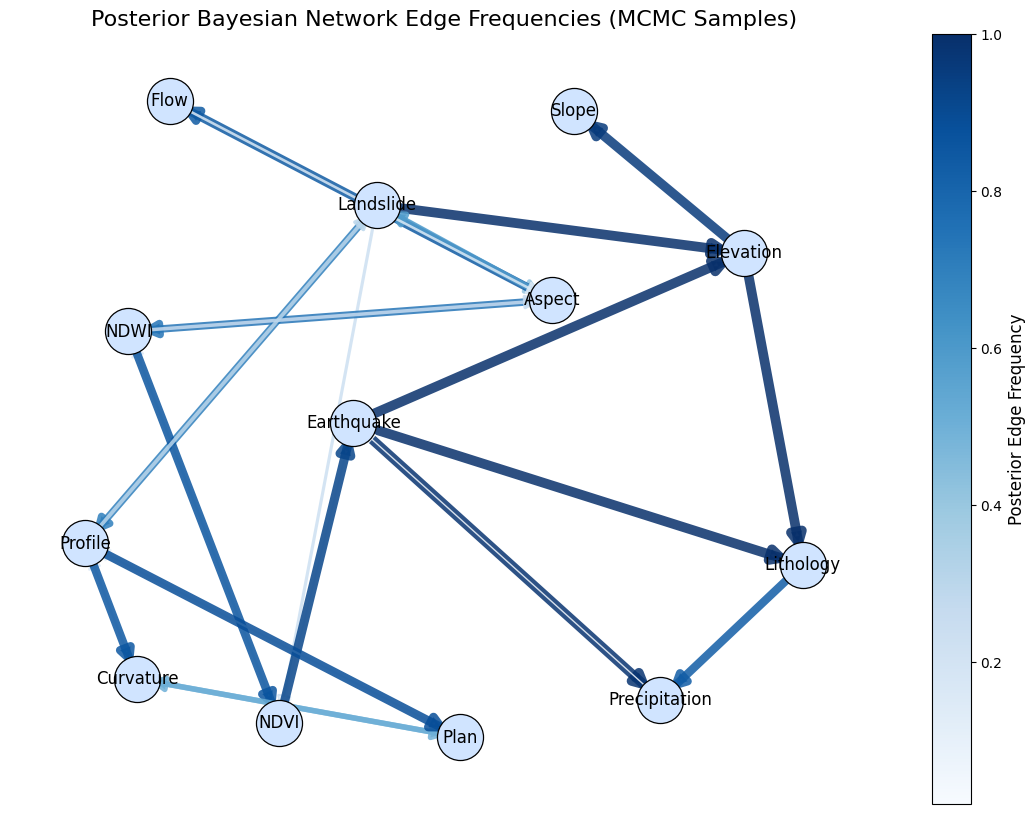

In [10]:


import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# -----------------------------
# Build weighted directed graph
# -----------------------------
G_freq = nx.DiGraph()
G_freq.add_nodes_from(nodes)

for (u, v), freq in edge_freq.items():
    G_freq.add_edge(u, v, weight=freq)

# Edge weights
weights = np.array([G_freq[u][v]["weight"] for u, v in G_freq.edges()])
min_w, max_w = weights.min(), weights.max()

# Edge thickness (scaled)
thickness = 1 + 6 * (weights - min_w) / (max_w - min_w + 1e-12)

# Edge color strength
colors = weights

# -----------------------------
# Create figure + axes explicitly
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 10))

# Node layout
pos = nx.spring_layout(G_freq, seed=42, k=1.5)

# Draw nodes
nx.draw_networkx_nodes(
    G_freq, pos, ax=ax,
    node_size=1100,
    node_color="#d0e4ff",
    edgecolors="black",
    linewidths=0.9
)

# Draw edges
nx.draw_networkx_edges(
    G_freq, pos, ax=ax,
    width=thickness,
    edge_color=colors,
    edge_cmap=plt.cm.Blues,
    arrowsize=20,
    alpha=0.85
)

# Draw labels
nx.draw_networkx_labels(G_freq, pos, ax=ax, font_size=12)

# -----------------------------
# Add colorbar — Proper Fix
# -----------------------------
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.Blues,
    norm=plt.Normalize(vmin=min_w, vmax=max_w)
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Posterior Edge Frequency", fontsize=12)

ax.set_title("Posterior Bayesian Network Edge Frequencies (MCMC Samples)", fontsize=16)
ax.axis("off")

plt.show()


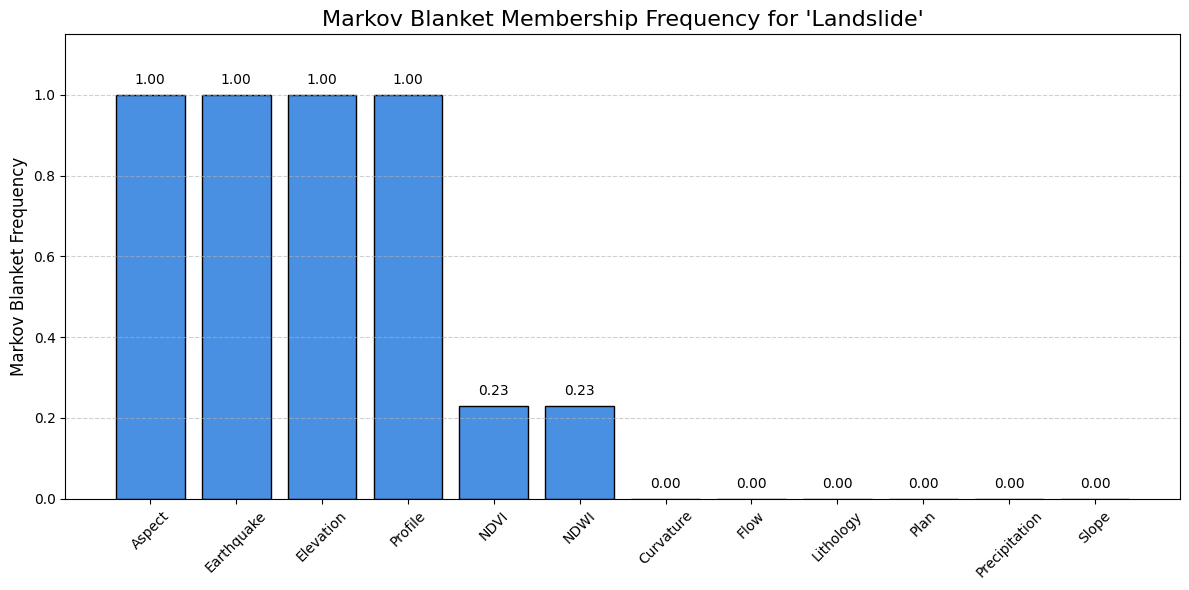

In [11]:
# ===========================================
# Cell 5 — Markov Blanket Frequency Plot (Variable Importance)
# ===========================================

import matplotlib.pyplot as plt
import numpy as np

# Sort MB frequencies from high to low
sorted_mb = sorted(mb_freq.items(), key=lambda x: -x[1])
vars_sorted = [v for v, _ in sorted_mb]
freqs_sorted = np.array([f for _, f in sorted_mb])

plt.figure(figsize=(12, 6))

# Bar chart
bars = plt.bar(vars_sorted, freqs_sorted, color="#4a90e2", edgecolor="black")

# Add numeric labels on bars
for bar, freq in zip(bars, freqs_sorted):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{freq:.2f}",
        ha="center", va="bottom", fontsize=10
    )

plt.ylim(0, 1.15)
plt.ylabel("Markov Blanket Frequency", fontsize=12)
plt.title(f"Markov Blanket Membership Frequency for '{TARGET}'", fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


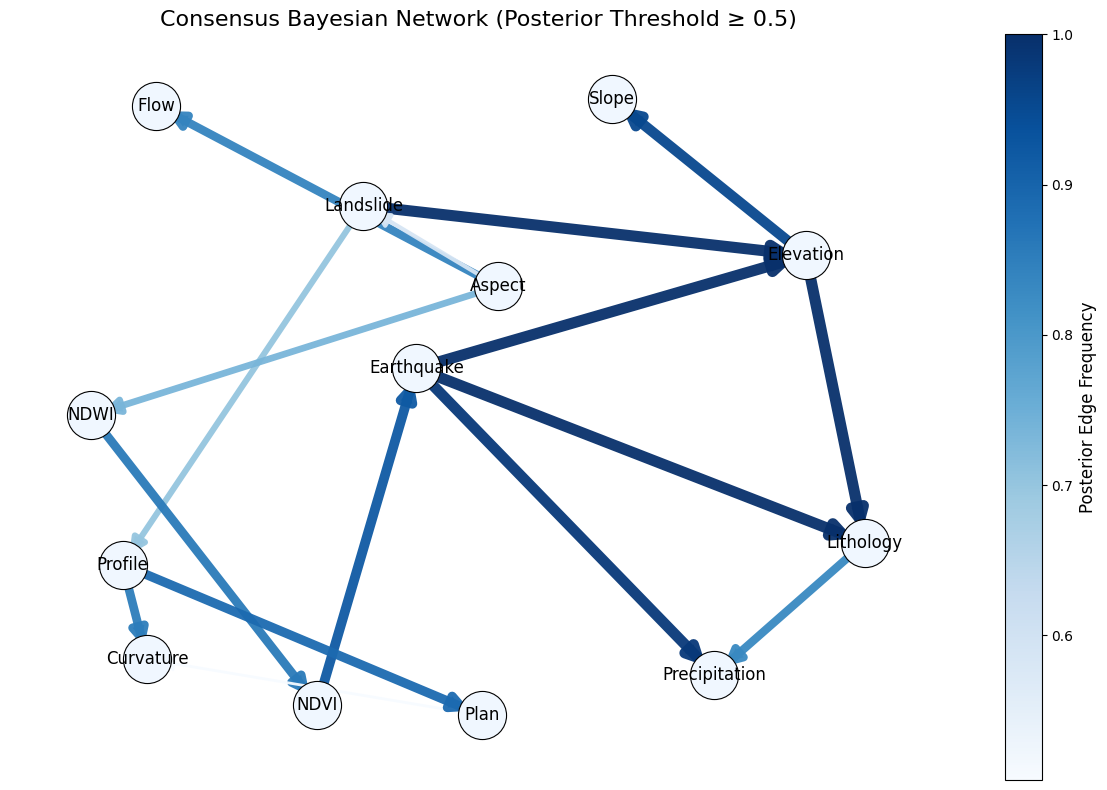

In [13]:
# ===========================================
# Cell 6 — Consensus DAG Visualization (Fixed)
# ===========================================

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Consensus graph from Cell 3
G_cons = consensus_G
edges = list(G_cons.edges())

# Edge weights = posterior frequency
edge_weights = [edge_freq.get(e, 0.0) for e in edges]
min_w, max_w = min(edge_weights), max(edge_weights)

# Normalized thickness
thickness = 2 + 6 * (np.array(edge_weights) - min_w) / (max_w - min_w + 1e-12)

# -------------------------------------------
# Create figure and axes explicitly
# -------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

# Node layout
pos = nx.spring_layout(G_cons, seed=42, k=1.4)

# Draw nodes
nx.draw_networkx_nodes(
    G_cons, pos, ax=ax,
    node_size=1200,
    node_color="#f0f7ff",
    edgecolors="black",
    linewidths=0.8
)

# Draw edges
nx.draw_networkx_edges(
    G_cons, pos, ax=ax,
    width=thickness,
    arrowsize=22,
    edge_color=edge_weights,
    edge_cmap=plt.cm.Blues,
    alpha=0.95
)

# Labels
nx.draw_networkx_labels(G_cons, pos, ax=ax, font_size=12)

# -------------------------------------------
# Colorbar — FIXED (attach to axes)
# -------------------------------------------
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.Blues,
    norm=plt.Normalize(vmin=min_w, vmax=max_w)
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Posterior Edge Frequency", fontsize=12)

# Title and final formatting
ax.set_title("Consensus Bayesian Network (Posterior Threshold ≥ 0.5)", fontsize=16)
ax.axis("off")
plt.tight_layout()

plt.show()


In [14]:
# ===========================================
# Cell 7 — Sensitivity Analysis Toolkit
# ===========================================

import numpy as np
import networkx as nx
from pgmpy.estimators import BDeuScore, HillClimbSearch

# ============================================================
# (A) Run Hill-Climb Only (for quick ESS sensitivity checking)
# ============================================================
def run_hc_model(data, ess=1.0):
    """
    Run a hill-climb BN structure learning with a given ESS.
    Useful as a fast approximation before running full MCMC.
    """
    scorer = BDeuScore(data, equivalent_sample_size=ess)
    hc = HillClimbSearch(data)
    model = hc.estimate(scoring_method=scorer)
    return set(model.edges())


# ============================================================
# (B) Compute edge frequencies from MCMC samples
# ============================================================
def compute_edge_freq(samples):
    freq = {}
    total = len(samples)

    for dag_edges in samples:
        for e in dag_edges:
            freq[e] = freq.get(e, 0) + 1

    # Normalize
    for e in freq:
        freq[e] /= total

    return freq


# ============================================================
# (C) Extract consensus graph with adjustable threshold
# ============================================================
def build_consensus_graph(edge_freq, threshold=0.5):
    """
    Build a consensus graph using adjustable posterior threshold.
    """
    G = nx.DiGraph()
    for (u, v), p in edge_freq.items():
        if p >= threshold:
            G.add_edge(u, v)

    # Remove cycles if they appear (break lowest freq edges)
    try:
        while not nx.is_directed_acyclic_graph(G):
            cycle = list(nx.find_cycle(G, orientation='original'))
            # pick weakest edge in the cycle
            weakest = min(cycle, key=lambda e: edge_freq.get((e[0], e[1]), 0))
            G.remove_edge(weakest[0], weakest[1])
    except nx.NetworkXNoCycle:
        pass

    return G


# ============================================================
# (D) MB Frequency (variable importance) sensitivity routine
# ============================================================
def compute_mb_freq(edge_freq, samples, target):
    """
    Compute Markov blanket frequencies for TARGET variable.
    """
    mb_counts = {v: 0 for v in nodes}

    for dag_edges in samples:
        G = nx.DiGraph()
        G.add_nodes_from(nodes)
        G.add_edges_from(dag_edges)

        parents = set(G.predecessors(target))
        children = set(G.successors(target))
        parents_of_children = set()

        for c in children:
            parents_of_children.update(G.predecessors(c))

        MB = parents | children | parents_of_children
        MB.discard(target)

        for v in MB:
            mb_counts[v] += 1

    total = len(samples)
    return {v: mb_counts[v] / total for v in nodes}


# ============================================================
# (E) High-level sensitivity runner
# ============================================================
def run_sensitivity(
        ess_list=[0.5, 1.0, 2.0, 5.0],
        thresh_list=[0.3, 0.5, 0.7],
        show_summary=True
):
    """
    Automatically run sensitivity tests for:
    - ESS changes (only HC for speed)
    - Threshold changes for consensus DAG

    Uses the MCMC posterior already computed earlier.
    """
    results = {}

    # 1. ESS sensitivity using hill climb (fast)
    ess_results = {}
    for ess in ess_list:
        edges = run_hc_model(train_disc, ess=ess)
        ess_results[ess] = edges

    # 2. Threshold sensitivity using MCMC arc posterior
    threshold_results = {}
    for t in thresh_list:
        Gc = build_consensus_graph(edge_freq, threshold=t)
        threshold_results[t] = list(Gc.edges())

    results["ess"] = ess_results
    results["threshold"] = threshold_results

    if show_summary:
        print("=== ESS Sensitivity (Hill-Climb) ===")
        for ess, edges in ess_results.items():
            print(f"ESS={ess}: {len(edges)} edges")

        print("\n=== Posterior Threshold Sensitivity (Consensus BN) ===")
        for t, edges in threshold_results.items():
            print(f"Threshold {t}: {len(edges)} edges")

    return results


In [16]:
results = run_sensitivity()


  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

=== ESS Sensitivity (Hill-Climb) ===
ESS=0.5: 13 edges
ESS=1.0: 17 edges
ESS=2.0: 16 edges
ESS=5.0: 17 edges

=== Posterior Threshold Sensitivity (Consensus BN) ===
Threshold 0.3: 16 edges
Threshold 0.5: 16 edges
Threshold 0.7: 14 edges
